# GraphSAGE Embeddings for Contig Binning

A mean-aggregator GraphSAGE graph autoencoder using adjacency-row, TNF, and coverage features, with RepBin-like marker cannot-link constraints.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. The shared loader uses `agtools.assemblers.spades.get_contig_graph` to load `tests/data/assembly_graph_with_scaffolds.gfa`, `tests/data/contigs.fasta`, and `tests/data/contigs.paths`. Node features follow the requested RepBin-like representation: the contig adjacency-matrix row plus 136 reverse-complement-collapsed normalized tetranucleotide frequencies plus z-scored `log1p` coverage parsed from SPAdes contig IDs. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']

# RepBin derives the expected number of bins from marker-gene constraints.
# Ground truth is used only after clustering to evaluate the predicted bins.
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'GraphSAGE'

class GraphSAGEEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, embedding_dim=32, dropout=0.25):
        super().__init__()
        self.lin1 = nn.Linear(in_dim * 2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim * 2, embedding_dim)
        self.dropout = dropout

    def sage_layer(self, x, adjacency, linear):
        mean_adj = normalized_adjacency(adjacency.numpy(), mode='mean')
        mean_adj = torch.tensor(mean_adj, dtype=torch.float32, device=x.device)
        neigh = mean_adj @ x
        return linear(torch.cat([x, neigh], dim=1))

    def forward(self, x, adjacency):
        h = self.sage_layer(x, adjacency, self.lin1)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        z = self.sage_layer(h, adjacency, self.lin2)
        return F.normalize(z, p=2, dim=1)

def run_once(seed):
    set_seed(seed)
    model = GraphSAGEEncoder(features.shape[1])
    embeddings, history = train_torch_graph_autoencoder(model, features, adjacency, marker_pairs)
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics['epochs'] = history[-1]['epoch']
    metrics['loss'] = history[-1]['loss']
    return metrics


run 01 seed=7: precision=0.9470, recall=0.8134, f1=0.8751, ari=0.7263, nmi=0.8309
run 02 seed=8: precision=0.9411, recall=0.8271, f1=0.8804, ari=0.7255, nmi=0.8187
run 03 seed=9: precision=0.9430, recall=0.8134, f1=0.8734, ari=0.7196, nmi=0.8227
run 04 seed=10: precision=0.9411, recall=0.8035, f1=0.8669, ari=0.7111, nmi=0.8128
run 05 seed=11: precision=0.9430, recall=0.8193, f1=0.8768, ari=0.7227, nmi=0.8236
run 06 seed=12: precision=0.9293, recall=0.8153, f1=0.8686, ari=0.7016, nmi=0.8056
run 07 seed=13: precision=0.9430, recall=0.8330, f1=0.8846, ari=0.7334, nmi=0.8270
run 08 seed=14: precision=0.9450, recall=0.8291, f1=0.8832, ari=0.7328, nmi=0.8327
run 09 seed=15: precision=0.9430, recall=0.8114, f1=0.8723, ari=0.7185, nmi=0.8224
run 10 seed=16: precision=0.9450, recall=0.8271, f1=0.8821, ari=0.7314, nmi=0.8322


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.946955,0.813360,0.875088,0.726328,0.830922,5,5,0.791695,310,1.068536
1,2,8,0.941061,0.827112,0.880415,0.725524,0.818662,5,5,0.799239,260,1.068407
2,3,9,0.943026,0.813360,0.873406,0.719626,0.822750,5,5,0.790734,332,1.068468
3,4,10,0.941061,0.803536,0.866878,0.711077,0.812751,5,5,0.783431,241,1.068656
4,5,11,0.943026,0.819253,0.876793,0.722749,0.823625,5,5,0.795044,317,1.068131
5,6,12,0.929273,0.815324,0.868577,0.701552,0.805617,5,5,0.791406,400,1.068057
6,7,13,0.943026,0.833006,0.884608,0.733378,0.826985,5,5,0.803572,303,1.068319
7,8,14,0.944990,0.829077,0.883247,0.732843,0.832662,5,5,0.801948,400,1.068416
8,9,15,0.943026,0.811395,0.872272,0.718518,0.822402,5,5,0.789460,330,1.069063
9,10,16,0.944990,0.827112,0.882131,0.731396,0.832217,5,5,0.800662,319,1.068145


,min,max,mean,std
precision,0.929273,0.946955,0.942043,0.004835
recall,0.803536,0.833006,0.819253,0.009445
f1,0.866878,0.884608,0.876341,0.006173
ari,0.701552,0.733378,0.722299,0.010118
nmi,0.805617,0.832662,0.822859,0.008715
aligned_macro_f1,0.783431,0.803572,0.794719,0.006477


<Axes: title={'center': 'GraphSAGE: mean metrics over 10 runs'}, ylabel='score'>

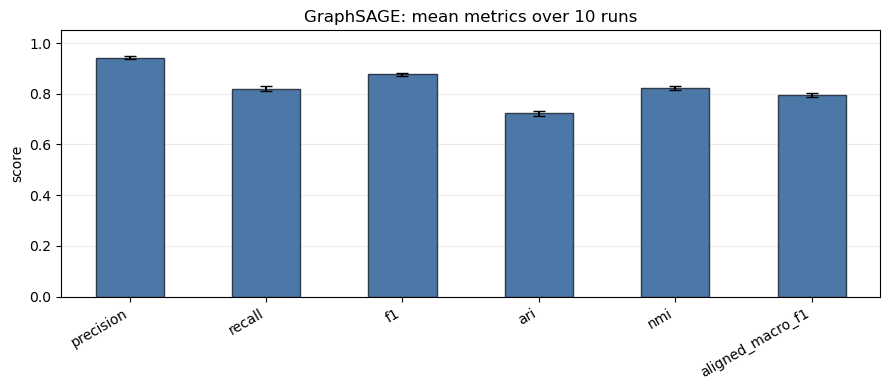

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.9449901768172888, 'recall': 0.8349705304518664, 'f1': 0.8865801879632401, 'ari': 0.737472462022596, 'nmi': 0.8340807170777872, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.8058242768729389, 'epochs': 383, 'loss': 1.068314790725708}
GraphSAGE: assembly graph coloured by predicted bin
bin 0: 100 contigs
bin 1: 115 contigs
bin 2: 120 contigs
bin 3: 71 contigs
bin 4: 103 contigs


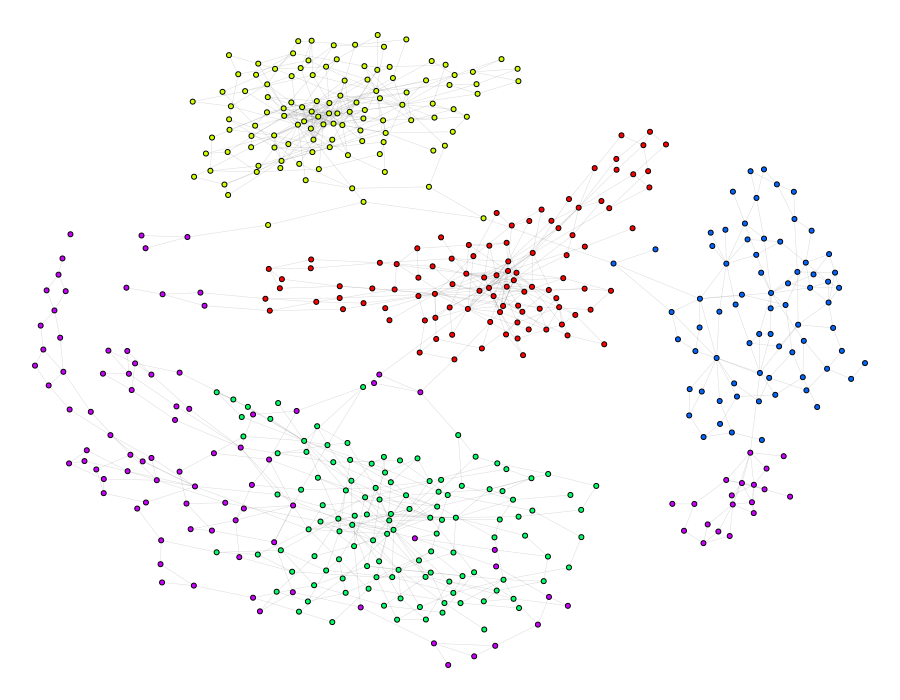

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.946955,0.834971,0.887444,0.739046,0.833864,5,5,0.805550,395,1.069124
1,original assembly graph,2,8,0.923379,0.793713,0.853650,0.677019,0.792109,5,5,0.777396,400,1.068570
2,original assembly graph,3,9,0.943026,0.813360,0.873406,0.719626,0.822750,5,5,0.790734,332,1.068291
3,original assembly graph,4,10,0.948919,0.815324,0.877064,0.730834,0.835594,5,5,0.791666,345,1.068035
4,original assembly graph,5,11,0.943026,0.821218,0.877917,0.724545,0.824278,5,5,0.795844,258,1.068406
5,original assembly graph,6,12,0.950884,0.817289,0.879040,0.734883,0.840878,5,5,0.794305,323,1.068268
6,original assembly graph,7,13,0.944990,0.833006,0.885471,0.735432,0.827552,5,5,0.803536,303,1.068537
7,original assembly graph,8,14,0.950884,0.834971,0.889166,0.747003,0.850564,5,5,0.806018,400,1.068238
8,original assembly graph,9,15,0.927308,0.809430,0.864369,0.694449,0.801831,5,5,0.787448,322,1.068551
9,original assembly graph,10,16,0.944990,0.831041,0.884360,0.733949,0.827099,5,5,0.802223,364,1.068687


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.923379  0.950884  0.942436  0.009492   
random edge removal              0.899804  0.925344  0.914538  0.007818   
random edge addition             0.886051  0.903733  0.895874  0.005239   
coverage-similarity edges added  0.823183  0.848723  0.837721  0.008397   
short contigs removed            0.908889  0.937778  0.922889  0.011761   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.793713  0.834971  0.820432  0.013395   
random edge removal              0.766208  0.799607  0.787819  0.009845   
random edge addition             0.770138  0.803536  0.788212  0.010429   
coverage-similarity edges added  0.746562  0.825147  0.795285  0.026044   
short contigs removed            0.802222  0.828889  0.813333  0.010683   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.853650  0.889166  ...  0.723679  0.021729   
random edge removal              0.835051  0.855351  ...  0.660086  0.015028   
random edge addition             0.826578  0.850694  ...  0.634998  0.012823   
coverage-similarity edges added  0.789170  0.829058  ...  0.576467  0.026756   
short contigs removed            0.853207  0.878998  ...  0.703148  0.023614   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.792109  0.850564  0.825652  0.017408   
random edge removal              0.749312  0.786972  0.769480  0.011689   
random edge addition             0.694078  0.722494  0.705794  0.010104   
coverage-similarity edges added  0.596950  0.635746  0.617604  0.013401   
short contigs removed            0.772664  0.823661  0.798330  0.018270   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.777396  0.806018  0.795472  0.009147  
random edge removal                     0.759137  0.779506  0.771706  0.006255  
random edge addition                    0.749628  0.773557  0.762091  0.007356  
coverage-similarity edges added         0.699635  0.784451  0.746911  0.027625  
short contigs removed                   0.778067  0.798043  0.786627  0.008021  

[5 rows x 24 columns]

<Axes: title={'center': 'GraphSAGE: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

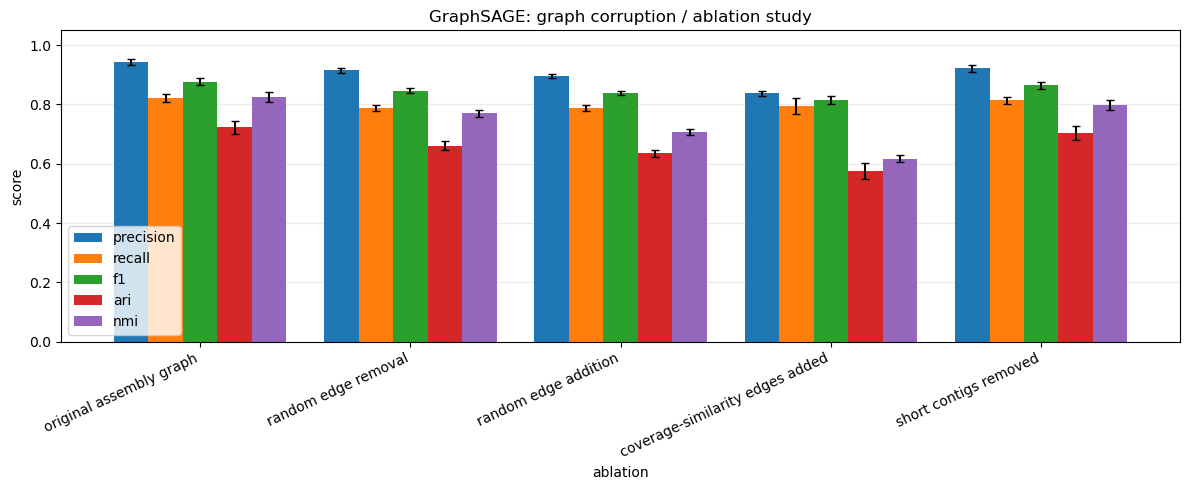

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
